# Caltrain delay exploration

An exploratory pass over the raw GPS pings collected from 511.org's `VehicleMonitoring` feed
(snapshot of the production SQLite DB on `pve-docker`).

The production pipeline (`src/flows/data_processing.py::process_arrival_data`) turns pings into
per-stop delays. A user review flagged three problems with it. This notebook re-derives arrivals
from scratch so the two can be compared:

| Review point | What production does | What this notebook does |
|---|---|---|
| Arrivals are anchored to the calendar day | Scheduled time = *date of the ping* + GTFS time, with `24:xx` wrapped to `00:xx`; negative delays are then zeroed | Each ping gets a **service date** (the day starts at 03:00); scheduled time = service date + raw GTFS `HH:MM:SS`, so `24:18` stays after midnight |
| `has_train_arrived(threshold=100)` is never called | Arrival = the ping closest to the stop, however far away | Arrival = first ping **within `ARRIVAL_RADIUS_M`** in a window around the scheduled time; otherwise, if two consecutive pings **bracket** the stop, the passing time is interpolated; otherwise *no confirmed arrival* |
| Cancellations are invisible | — | Scheduled trains with **no pings at all** are counted per day (a proxy), and there's an optional live look at the `TripUpdates` feed |

Along the way it turns up a few things the review didn't mention: collector blind spots,
the timetable being out of date, the realtime `stop_id` switching early, and trains dropping out
of the feed before their final stop.

**Refreshing the data.** Take a consistent snapshot of the live DB into `data/` (the SQLite
backup API is safe while the collector is writing):

```bash
ssh jsakkos@192.168.1.122 'cd ~/caltrain-prefect && .venv/bin/python -c "import sqlite3; s=sqlite3.connect(\"file:data/caltrain_lat_long.db?mode=ro\", uri=True); d=sqlite3.connect(\"/tmp/caltrain_snapshot.db\"); s.backup(d); d.close()"'
scp jsakkos@192.168.1.122:/tmp/caltrain_snapshot.db data/caltrain_lat_long.db
ssh jsakkos@192.168.1.122 'rm /tmp/caltrain_snapshot.db'
```

## Setup

In [1]:
import os
import sqlite3
import sys
from contextlib import closing
from datetime import timedelta
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "gtfs_data").is_dir())
DB_PATH = Path(os.environ.get("CALTRAIN_DB", ROOT / "data" / "caltrain_lat_long.db"))

# Every schedule version lives in gtfs_feeds/; src/data/gtfs_feeds.py picks one per service date
# (511's monthly archive of what actually ran first, else the newest published timetable in effect).
sys.path.insert(0, str(ROOT))
from src.data.gtfs_feeds import active_service_ids, discover_feeds, feed_for_date  # noqa: E402

FEEDS_DIR = ROOT / "gtfs_feeds"
LEGACY_GTFS = FEEDS_DIR / "v20240920"  # the stale timetable production scored every arrival against until Sep 2026

SERVICE_DAY_START_HOUR = 3    # pings before 03:00 belong to the previous service day
ARRIVAL_RADIUS_M = 400        # see the distance distribution in section 3
WINDOW = (pd.Timedelta(minutes=-10), pd.Timedelta(hours=4))  # pings considered for a stop, relative to its scheduled time
BRACKET_MAX_GAP_S = 180       # two pings may bracket a stop only if they're this close in time
ON_TIME_MIN = 5               # Caltrain's OTP standard: < 5 min late
SEVERE_MIN = 60

# Chart palette. Categorical slots validated for CVD + normal-vision separation on the light surface.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SEVERITY = {  # status colors: always paired with a text label
    "On time (<5)": "#0ca30c", "Minor (5–15)": "#fab219",
    "Major (15–60)": "#ec835a", "Severe (60+)": "#d03b3b",
}
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "figure.figsize": (11, 4.2),
    "font.family": ["Segoe UI", "Arial", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "lines.linewidth": 2,
})
pd.set_option("display.width", 160, "display.max_columns", 30)
thousands = FuncFormatter(lambda v, _: f"{v:,.0f}")
month_axis = lambda ax: (ax.xaxis.set_major_locator(mdates.MonthLocator()),
                         ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y")))


def haversine_m(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6_371_000 * 2 * np.arcsin(np.sqrt(a))


def gtfs_seconds(hms: pd.Series) -> pd.Series:
    """'24:18:00' -> 87480. GTFS times may exceed 24h; never wrap them."""
    parts = hms.str.split(":", expand=True).astype(int)
    return parts[0] * 3600 + parts[1] * 60 + parts[2]


def severity(delay_min: pd.Series) -> pd.Categorical:
    return pd.cut(delay_min, [-np.inf, ON_TIME_MIN, 15, SEVERE_MIN, np.inf], right=False, labels=list(SEVERITY))

## Load raw pings

In [2]:
with closing(sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro", uri=True)) as conn:
    pings = pd.read_sql_query(
        "SELECT trip_id AS train, stop_id, vehicle_lat AS lat, vehicle_lon AS lon, timestamp FROM train_locations", conn)

pings["timestamp"] = pd.to_datetime(pings["timestamp"], format="ISO8601")
pings["service_date"] = (pings["timestamp"] - pd.Timedelta(hours=SERVICE_DAY_START_HOUR)).dt.normalize()
print(f"{len(pings):,} pings  |  {pings.timestamp.min():%Y-%m-%d %H:%M} → {pings.timestamp.max():%Y-%m-%d %H:%M}"
      f"  |  {pings.train.nunique():,} distinct VehicleRefs")

4,332,627 pings  |  2025-08-10 11:14 → 2026-09-14 21:07  |  1,097 distinct VehicleRefs


## 1. What does the collector actually see?

Each cell is one hour on one date, shaded by how many distinct polling minutes produced data.
Before trusting any delay number, it's worth knowing where the blind spots are.

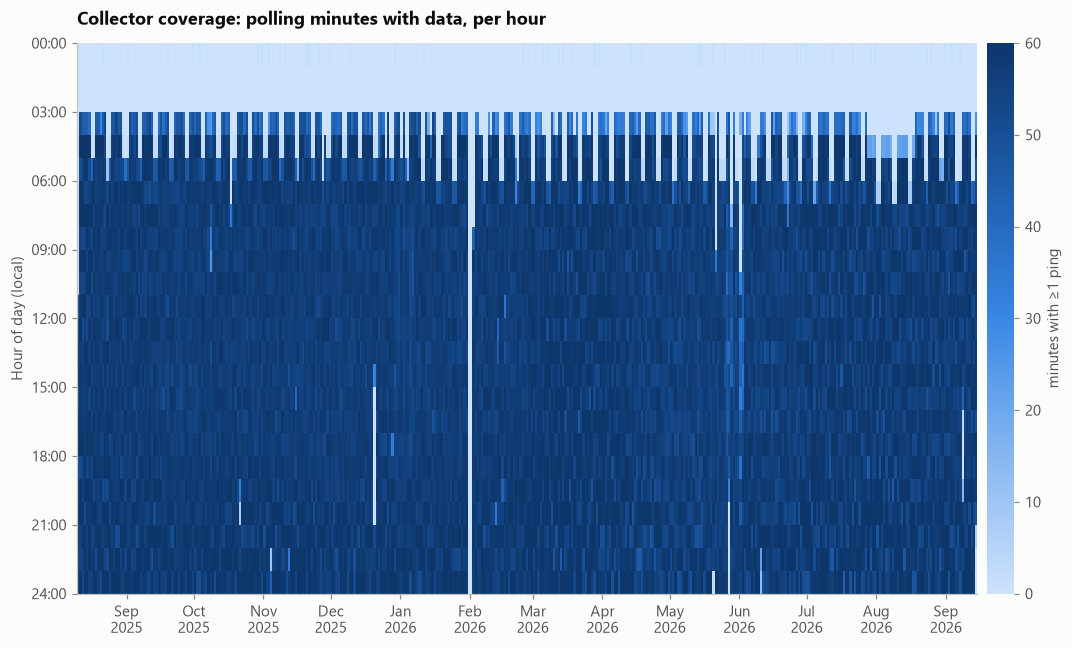

Polling minutes between 00:00 and 03:00: 47 of 72,180 possible across 401 nights.
Days with <25% of the median day's polling minutes (collector outages): 2026-01-31, 2026-02-01


In [3]:
minute = pings["timestamp"].dt.floor("min").drop_duplicates()
cov = (pd.DataFrame({"date": minute.dt.normalize(), "hour": minute.dt.hour})
       .groupby(["date", "hour"]).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0))
cov = cov.reindex(pd.date_range(cov.index.min(), cov.index.max()), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(cov.T.values, aspect="auto", cmap=SEQ, vmin=0, vmax=60, interpolation="nearest",
               extent=[mdates.date2num(cov.index[0]), mdates.date2num(cov.index[-1] + pd.Timedelta(days=1)), 24, 0])
month_axis(ax)
ax.set_yticks(range(0, 25, 3)); ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 25, 3)])
ax.grid(False); ax.set_ylabel("Hour of day (local)")
ax.set_title("Collector coverage: polling minutes with data, per hour")
cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.03); cb.set_label("minutes with ≥1 ping", color=INK2); cb.outline.set_visible(False)
plt.show()

print(f"Polling minutes between 00:00 and 03:00: {cov.loc[:, [0, 1, 2]].values.sum():,} of {len(cov) * 180:,} possible "
      f"across {len(cov)} nights.")
daily_minutes = cov.sum(axis=1)
print("Days with <25% of the median day's polling minutes (collector outages):",
      ", ".join(f"{d:%Y-%m-%d}" for d in daily_minutes[daily_minutes < 0.25 * daily_minutes.median()].index) or "none")

The empty band from midnight to ~03:00 is **not** a lack of trains: weekday trains 172/174/176
are scheduled into `24:xx`. The daily processing flow is on cron `0 0 * * *`, reloads every ping
in the DB, and appears to block the once-a-minute collector until it finishes. So post-midnight
arrivals aren't only mis-scored by the calendar-date bug; they mostly **never get recorded**.
Moving processing off the collector's worker, or making it incremental, would close the gap.
The light early-morning strip on weekends is real: weekend service starts later.

## 2. Build the scheduled timetable per service date

Each service date is scored against the schedule `src/data/gtfs_feeds.py` picks for it:

- **`historic-YYYY-MM`**: the Caltrain subset of 511's monthly regional archive. It lists the trips
  that actually ran on each day, including holidays and mid-month timetable changes.
- **`v<feed_version>`**: published feeds, used where no archive exists yet (the current month). The
  newest timetable in effect wins.

Published feeds only list holiday exceptions from their publish date forward, so for dates scored
against one, the notebook also tries that week's Sunday timetable and keeps whichever matches the
trains actually observed. Archives don't need this. Modified-service trips such as `M101` report
their plain train number (`101`) in the realtime feed, so the join key is `trip_short_name` with
the `M` stripped.

In [4]:
feeds = discover_feeds(FEEDS_DIR)
display(pd.DataFrame([(f.path.name, f.start, f.end) for f in feeds], columns=["schedule", "first date", "last date"])
        .style.hide(axis="index"))


@lru_cache(maxsize=None)
def feed_frames(folder: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    read = lambda name: pd.read_csv(folder / f"{name}.txt", dtype=str, keep_default_na=False)
    trips = read("trips")
    trips = trips.assign(train=trips.trip_short_name.where(trips.trip_short_name != "", trips.trip_id).str.lstrip("M"),
                         direction=np.where(trips.direction_id == "0", "Northbound", "Southbound"))
    st = read("stop_times").assign(sched_s=lambda d: gtfs_seconds(d.arrival_time),
                                   stop_sequence=lambda d: d.stop_sequence.astype(int))
    return (trips[["trip_id", "service_id", "train", "route_id", "direction"]],
            st[["trip_id", "stop_id", "stop_sequence", "sched_s"]])


# Station names and platform coordinates come from the newest published timetable, so every feed labels stops alike
newest = max((f for f in feeds if not f.historic), key=lambda f: f.start)
stops = pd.read_csv(newest.path / "stops.txt", dtype=str, keep_default_na=False)
platforms = (stops[stops.parent_station != ""]
             .assign(station=lambda d: d.parent_station.map(stops.set_index("stop_id").stop_name),
                     stop_lat=lambda d: d.stop_lat.astype(float), stop_lon=lambda d: d.stop_lon.astype(float))
             [["stop_id", "station", "stop_lat", "stop_lon"]])

seen_by_date = pings.groupby("service_date")["train"].agg(set)
rows, overrides, uncovered = [], [], []
for d, seen in seen_by_date.items():
    day = d.date()
    feed = feed_for_date(day, feeds)
    if feed is None:
        uncovered.append(d)
        continue
    chosen = active_service_ids(feed, day)
    if not feed.historic:
        trips, _ = feed_frames(feed.path)
        running = lambda sids: len(seen & set(trips.loc[trips.service_id.isin(sids), "train"]))
        weekend = active_service_ids(feed, day + timedelta(days=6 - day.weekday()))
        if running(weekend) > running(chosen):
            chosen = weekend
            overrides.append(d)
    rows += [(d, feed.path.name, sid) for sid in chosen]

active = pd.DataFrame(rows, columns=["service_date", "feed", "service_id"])
parts = []
for name, days in active.groupby("feed"):
    trips, st = feed_frames(FEEDS_DIR / name)
    parts.append(days.merge(trips, on="service_id").merge(st, on="trip_id").merge(platforms, on="stop_id"))

sched = pd.concat(parts, ignore_index=True).sort_values(["service_date", "train", "stop_sequence"], ignore_index=True)
sched["scheduled"] = sched["service_date"] + pd.to_timedelta(sched["sched_s"], unit="s")
by_run = sched.groupby(["service_date", "train"])
sched["stop_idx"] = by_run.cumcount()
sched["stops_to_end"] = by_run["stop_idx"].transform("max") - sched["stop_idx"]
sched["is_origin"], sched["is_terminal"] = sched.stop_idx.eq(0), sched.stops_to_end.eq(0)

KEYS = ["service_date", "train", "stop_id"]
assert not sched.duplicated(KEYS).any(), "a (date, train, stop) is scheduled twice"
print(f"{len(sched):,} scheduled stop-calls across {by_run.ngroups:,} train-days")
print("Service dates per schedule:", active.drop_duplicates("service_date").groupby("feed").size().to_dict())
print("Dates with no schedule:", ", ".join(f"{d:%Y-%m-%d}" for d in uncovered) or "none")
print("Published-feed dates run on the weekend timetable despite its calendar:",
      ", ".join(f"{d:%a %Y-%m-%d}" for d in overrides) or "none")

known = pings["train"].isin(sched["train"].unique())
print(f"Dropping {(~known).sum():,} pings ({(~known).mean():.2%}) whose VehicleRef isn't a scheduled train number "
      f"(e.g. {', '.join(pings.loc[~known, 'train'].value_counts().index[:5])})")
pings = pings[known].sort_values(["service_date", "train", "timestamp"], ignore_index=True)
pings["run"] = pings.groupby(["service_date", "train"], sort=False).ngroup()

schedule,first date,last date
historic-2025-08,2025-08-01,2025-08-31
historic-2025-09,2025-09-01,2025-09-30
historic-2025-10,2025-10-01,2025-10-31
historic-2025-11,2025-11-01,2025-11-30
historic-2025-12,2025-12-01,2025-12-31
historic-2026-01,2026-01-01,2026-01-31
historic-2026-02,2026-02-01,2026-02-28
historic-2026-03,2026-03-01,2026-03-31
historic-2026-04,2026-04-01,2026-04-30
historic-2026-05,2026-05-01,2026-05-31


776,486 scheduled stop-calls across 39,089 train-days
Service dates per schedule: {'historic-2025-08': 22, 'historic-2025-09': 30, 'historic-2025-10': 31, 'historic-2025-11': 30, 'historic-2025-12': 31, 'historic-2026-01': 30, 'historic-2026-02': 27, 'historic-2026-03': 31, 'historic-2026-04': 30, 'historic-2026-05': 31, 'historic-2026-06': 30, 'historic-2026-07': 31, 'historic-2026-08': 31, 'v20260611': 14}
Dates with no schedule: none
Published-feed dates run on the weekend timetable despite its calendar: none
Dropping 913 pings (0.02%) whose VehicleRef isn't a scheduled train number (e.g. 2057, 0130, 0131, 0132, 0134)


## 3. Detecting arrivals

### The realtime `stop_id` can't be trusted to mean "at this stop"

Production matches each ping only against the stop named in the ping (`MonitoredCall`). Here is one
morning of train 101. The feed switches to the *next* stop while the train is still at, or pulling
out of, the current one. So the ping taken at the platform is labelled with the following
station, and production never sees it.

In [5]:
demo_date = pings.loc[(pings.train == "101") & (pings.service_date.dt.dayofweek < 5), "service_date"].max()
demo = pings[(pings.train == "101") & (pings.service_date == demo_date)]
demo_stops = sched[(sched.train == "101") & (sched.service_date == demo_date)]
D = haversine_m(demo.lat.values[:, None], demo.lon.values[:, None], demo_stops.stop_lat.values[None, :], demo_stops.stop_lon.values[None, :])
reported = demo.merge(demo_stops[["stop_id", "stop_lat", "stop_lon"]], on="stop_id", how="left")
view = pd.DataFrame({
    "time": demo.timestamp.dt.strftime("%H:%M:%S").values,
    "reported stop": reported.stop_id.map(demo_stops.set_index("stop_id").station).values,
    "m to reported stop": haversine_m(reported.lat, reported.lon, reported.stop_lat, reported.stop_lon).round().values,
    "actually nearest stop": demo_stops.station.values[D.argmin(1)],
    "m to nearest stop": D.min(1).round(),
})
print(f"Train 101 on {demo_date:%a %Y-%m-%d}")
view.iloc[8:26].style.hide(axis="index").apply(
    lambda r: ["background-color: #fdebd0" if (r["reported stop"] != r["actually nearest stop"]) and r["m to nearest stop"] < ARRIVAL_RADIUS_M else "" for _ in r], axis=1)

Train 101 on Mon 2026-09-14


time,reported stop,m to reported stop,actually nearest stop,m to nearest stop
04:34:58,Tamien Caltrain Station,166.000000,Tamien Caltrain Station,166.000000
04:35:58,Tamien Caltrain Station,166.000000,Tamien Caltrain Station,166.000000
04:36:58,San Jose Diridon,2422.000000,Tamien Caltrain Station,166.000000
04:37:58,San Jose Diridon,2335.000000,Tamien Caltrain Station,254.000000
04:38:58,San Jose Diridon,1606.000000,Tamien Caltrain Station,985.000000
04:39:58,San Jose Diridon,1105.000000,San Jose Diridon,1105.000000
04:40:58,San Jose Diridon,791.000000,San Jose Diridon,791.000000
04:41:58,San Jose Diridon,339.000000,San Jose Diridon,339.000000
04:42:58,Santa Clara Caltrain Station,3903.000000,San Jose Diridon,85.000000
04:43:58,Santa Clara Caltrain Station,3896.000000,San Jose Diridon,96.000000


So each scheduled stop is matched against **every ping of its train** within a window around the
scheduled time, whatever `stop_id` the ping reports:

1. **Confirmed**: the first ping within `ARRIVAL_RADIUS_M` of the platform.
2. **Interpolated**: no ping landed that close, but the nearest ping and its neighbour (≤ 3 min apart)
   lie on opposite sides of the stop. The passing time is interpolated by distance. This is
   the geometric version of `has_train_arrived`: the train provably went past.
3. Otherwise there is **no confirmed arrival**. A train that never gets near a stop, or that
   stops and turns back, no longer produces a phantom arrival.

In [6]:
P_LAT, P_LON, P_TS, P_RUN = (pings[c].to_numpy() for c in ["lat", "lon", "timestamp", "run"])


def detect(month_pings: pd.DataFrame, month_sched: pd.DataFrame) -> pd.DataFrame:
    x = (month_pings[["service_date", "train", "timestamp"]].reset_index(names="pid")
         .merge(month_sched[KEYS + ["scheduled", "stop_lat", "stop_lon"]], on=["service_date", "train"]))
    x = x[(x.timestamp >= x.scheduled + WINDOW[0]) & (x.timestamp <= x.scheduled + WINDOW[1])]
    x["dist_m"] = haversine_m(P_LAT[x.pid], P_LON[x.pid], x.stop_lat.to_numpy(), x.stop_lon.to_numpy())

    near = x.loc[x.groupby(KEYS, sort=False)["dist_m"].idxmin()]
    first_within = (x[x.dist_m <= ARRIVAL_RADIUS_M].sort_values("timestamp").drop_duplicates(KEYS)
                    .set_index(KEYS)["timestamp"].rename("first_within"))

    pid, d1, t1 = near.pid.to_numpy(), near.dist_m.to_numpy(), near.timestamp.to_numpy()
    s_lat, s_lon = near.stop_lat.to_numpy(), near.stop_lon.to_numpy()
    best_t, best_d = np.full(len(near), np.datetime64("NaT", "ns")), np.full(len(near), np.inf)
    for step in (-1, 1):
        j = np.clip(pid + step, 0, len(P_TS) - 1)
        d2 = haversine_m(P_LAT[j], P_LON[j], s_lat, s_lon)
        span = haversine_m(P_LAT[j], P_LON[j], P_LAT[pid], P_LON[pid])
        gap_s = np.abs(P_TS[j] - t1) / np.timedelta64(1, "s")
        brackets = ((j != pid) & (P_RUN[j] == P_RUN[pid]) & (gap_s <= BRACKET_MAX_GAP_S)
                    & (np.maximum(d1, d2) <= 3_000) & (d1 + d2 <= 1.1 * span + 100) & (d2 < best_d))
        t_cross = t1 + (P_TS[j] - t1) * (d1 / np.maximum(d1 + d2, 1e-9))
        best_t, best_d = np.where(brackets, t_cross, best_t), np.where(brackets, d2, best_d)

    out = near[KEYS + ["dist_m"]].rename(columns={"dist_m": "nearest_m"}).assign(interpolated=best_t)
    return out.join(first_within, on=KEYS)


months = pings.service_date.dt.to_period("M")
sched_months = sched.service_date.dt.to_period("M")
det = pd.concat([detect(pings[months == m], sched[sched_months == m]) for m in months.unique()], ignore_index=True)

runs_seen = pings[["service_date", "train"]].drop_duplicates().assign(train_seen=True)
arr = (sched.merge(det, on=KEYS, how="left").merge(runs_seen, on=["service_date", "train"], how="left"))
arr["train_seen"] = arr["train_seen"].astype("boolean").fillna(False).astype(bool)
arr["actual"] = arr["first_within"].fillna(arr["interpolated"])
arr["method"] = np.select(
    [arr.first_within.notna(), arr.interpolated.notna(), arr.nearest_m.notna(), arr.train_seen],
    ["confirmed (ping ≤ radius)", "interpolated (bracketed)", "pinged nearby, not placed", "train seen, no pings in window"],
    default="train never seen")
arr["delay_min"] = (arr["actual"] - arr["scheduled"]).dt.total_seconds() / 60
arr["severity"] = severity(arr["delay_min"])
arr["weekday"] = arr["service_date"].dt.day_name().str[:3]

print((arr.groupby(["is_origin", "method"]).size().unstack(0, fill_value=0)
       .rename(columns={False: "intermediate & final stops", True: "origin stops"})).to_string())

is_origin                       intermediate & final stops  origin stops
method                                                                  
confirmed (ping ≤ radius)                           607325         37950
interpolated (bracketed)                             11197             0
pinged nearby, not placed                            93262           745
train never seen                                      6141           363
train seen, no pings in window                       19472            31


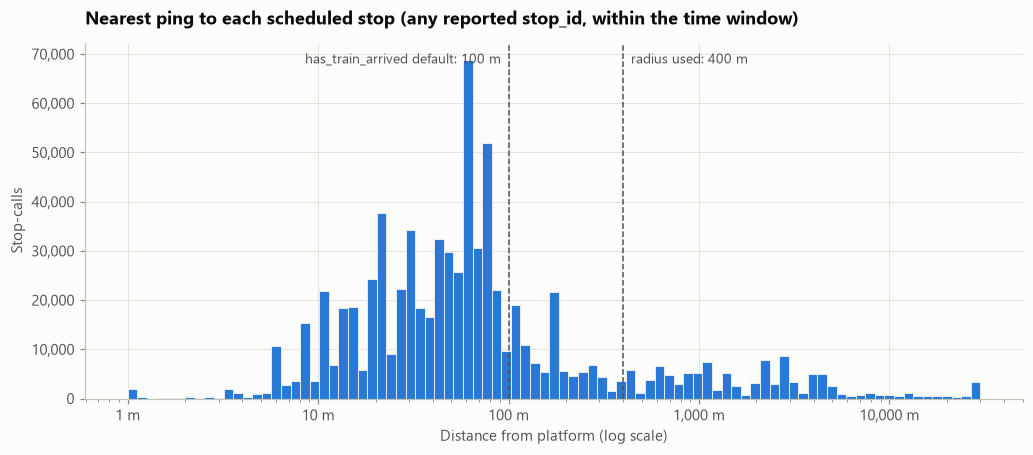

≤100 m: 73.0%  ≤200 m: 82.2%  ≤400 m: 86.0%  ≤800 m: 89.1%  ≤1,600 m: 92.9%


In [7]:
fig, ax = plt.subplots()
bins = np.logspace(0, np.log10(30_000), 90)
ax.hist(arr["nearest_m"].dropna().clip(1, 30_000), bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f} m")); ax.yaxis.set_major_formatter(thousands)
top = ax.get_ylim()[1]
for x, label, side in [(100, "has_train_arrived default: 100 m", "right"), (ARRIVAL_RADIUS_M, f"radius used: {ARRIVAL_RADIUS_M} m", "left")]:
    ax.axvline(x, color=INK2, linewidth=1, linestyle="--")
    ax.annotate(label, (x, top * 0.97), xytext=(-5 if side == "right" else 5, 0), textcoords="offset points",
                ha=side, color=INK2, va="top", fontsize=9)
ax.set_title("Nearest ping to each scheduled stop (any reported stop_id, within the time window)")
ax.set_xlabel("Distance from platform (log scale)"); ax.set_ylabel("Stop-calls")
plt.show()
near = arr["nearest_m"].dropna()
print("  ".join(f"≤{r:,} m: {(near <= r).mean():.1%}" for r in [100, 200, 400, 800, 1600]))

With one ping a minute and trains covering up to ~2 km between pings, a 100 m radius throws away
far more real stops than it rejects phantoms. The second hump near 1 km is mostly minutes where
the ping fell just before arrival and just after departure. Interpolation rescues the cases where
those two pings bracket the stop.

### Trains vanish from the feed before their final stop

One more blind spot: 511 stops listing a train a few minutes before it reaches its terminal.
Delay **at the final stop** (Caltrain's own OTP definition) therefore can't be measured from this
feed. Trip-level numbers below use each train's **last placed stop**, and only for runs that were
tracked to within 3 stops of the end.

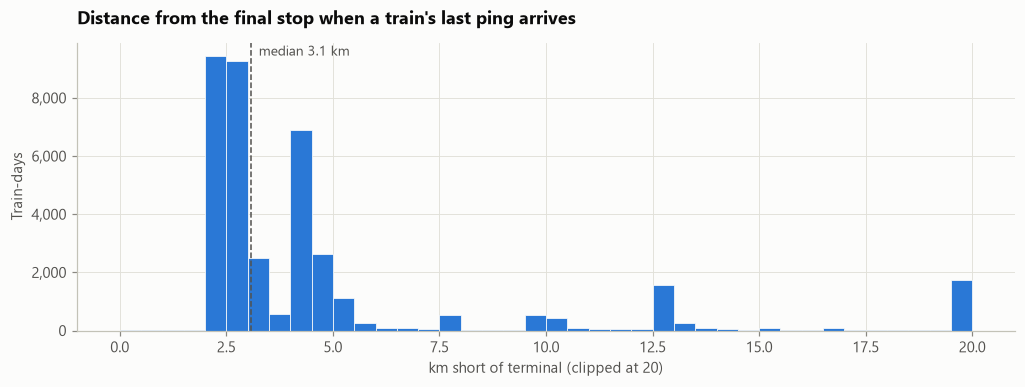

final stops placed: 0.0%


placed stop arrivals: 618,522   train-days with an end-of-run delay: 35,908 of 39,089 scheduled


In [8]:
last_ping = pings.groupby("run").tail(1)[["service_date", "train", "timestamp", "lat", "lon"]]
term = sched.loc[sched.is_terminal, ["service_date", "train", "scheduled", "stop_lat", "stop_lon"]]
lt = last_ping.merge(term, on=["service_date", "train"])
lt["km_short"] = haversine_m(lt.lat, lt.lon, lt.stop_lat, lt.stop_lon) / 1000

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(lt.km_short.clip(upper=20), bins=np.arange(0, 20.5, 0.5), color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(lt.km_short.median(), color=INK2, linewidth=1, linestyle="--")
ax.annotate(f"median {lt.km_short.median():.1f} km", (lt.km_short.median(), 1), xycoords=("data", "axes fraction"),
            xytext=(5, -2), textcoords="offset points", va="top", color=INK2, fontsize=9)
ax.set_title("Distance from the final stop when a train's last ping arrives")
ax.set_xlabel("km short of terminal (clipped at 20)"); ax.set_ylabel("Train-days"); ax.yaxis.set_major_formatter(thousands)
plt.show()
print(f"final stops placed: {arr.loc[arr.is_terminal, 'actual'].notna().mean():.1%}")

placed = arr[arr.actual.notna() & ~arr.is_origin]
stop_level = placed                                     # one row per placed (non-origin) stop arrival
trip_end = placed.sort_values("stop_idx").groupby(["service_date", "train"]).tail(1)
trip_end = trip_end[trip_end.stops_to_end <= 3]         # one row per train-day, delay at its last placed stop
print(f"placed stop arrivals: {len(stop_level):,}   train-days with an end-of-run delay: {len(trip_end):,} "
      f"of {sched[['service_date', 'train']].drop_duplicates().shape[0]:,} scheduled")

## 4. Reproduce the production pipeline for comparison

A vectorized copy of `process_arrival_data`: same GTFS folder, same calendar-date anchoring, same
`normalize_time` wrap, same closest-ping-to-reported-stop rule, same clipping. It also exposes one
more quirk. Production merges per-stop arrivals back onto *every ping* for that stop, so
`processed_arrivals.csv` holds roughly one row per ping, not per arrival, and every mean and share
built from it is weighted by how many minutes a train spent approaching that stop.

In [9]:
lg_stops = pd.read_csv(LEGACY_GTFS / "stops.txt", dtype=str)
lg_stops = lg_stops[lg_stops.stop_id.str.isnumeric()].astype({"stop_lat": float, "stop_lon": float})
lg_st = pd.read_csv(LEGACY_GTFS / "stop_times.txt", dtype=str)

lg = (pings[["train", "stop_id", "lat", "lon", "timestamp"]]
      .merge(lg_st[["trip_id", "stop_id", "arrival_time"]], left_on=["train", "stop_id"], right_on=["trip_id", "stop_id"])
      .merge(lg_stops[["stop_id", "stop_lat", "stop_lon"]], on="stop_id"))
lg["dist"] = haversine_m(lg.lat.values, lg.lon.values, lg.stop_lat.values, lg.stop_lon.values)
lg["date"] = lg["timestamp"].dt.normalize()
LG_KEYS = ["train", "stop_id", "date"]
prod = lg.loc[lg.groupby(LG_KEYS, sort=False)["dist"].idxmin(), LG_KEYS + ["timestamp", "arrival_time"]]
prod["legacy_sched_s"] = gtfs_seconds(prod["arrival_time"])
prod["raw_delay_min"] = ((prod["timestamp"] - prod["date"]).dt.total_seconds() - prod["legacy_sched_s"] % 86_400) / 60
prod["delay_min"] = prod["raw_delay_min"].where(prod.raw_delay_min.between(-100, 500), 0.0).clip(lower=0)

rows_per_arrival = lg.groupby(LG_KEYS, sort=False).size()
print(f"production-style arrivals: {len(prod):,}; rows production writes: {rows_per_arrival.sum():,} "
      f"(×{rows_per_arrival.mean():.1f} per arrival)")
print(f"raw delays zeroed: >500 min {(prod.raw_delay_min > 500).sum():,} | <−100 min {(prod.raw_delay_min < -100).sum():,} "
      f"| between −100 and 0 {prod.raw_delay_min.between(-100, 0, inclusive='neither').sum():,}")

# Line up production against the corrected table (same train, stop, and — for daytime pings — date)
both = prod.merge(arr[KEYS + ["sched_s", "delay_min", "method"]].rename(columns={"service_date": "date", "delay_min": "corr_delay"}),
                  on=LG_KEYS, how="left")
tt = (both.legacy_sched_s - both.sched_s).dropna() / 60
print(f"production arrivals scored against a stale timetable time (|Δ| ≥ 1 min vs. the timetable in effect): "
      f"{(tt.abs() >= 1).mean():.1%} (median |Δ| where different: {tt[tt.abs() >= 1].abs().median():.0f} min)")

production-style arrivals: 700,746; rows production writes: 4,320,313 (×6.2 per arrival)
raw delays zeroed: >500 min 1,173 | <−100 min 307 | between −100 and 0 343,213


production arrivals scored against a stale timetable time (|Δ| ≥ 1 min vs. the timetable in effect): 39.8% (median |Δ| where different: 1 min)


## 5. The delay histogram

Stop-level arrival delay for every placed arrival, excluding origins (where "arrival" is just the
train waiting on the platform), in one-minute bins. The y-axis is logarithmic; otherwise the
hour-plus delays are invisible next to hundreds of thousands of on-time arrivals.

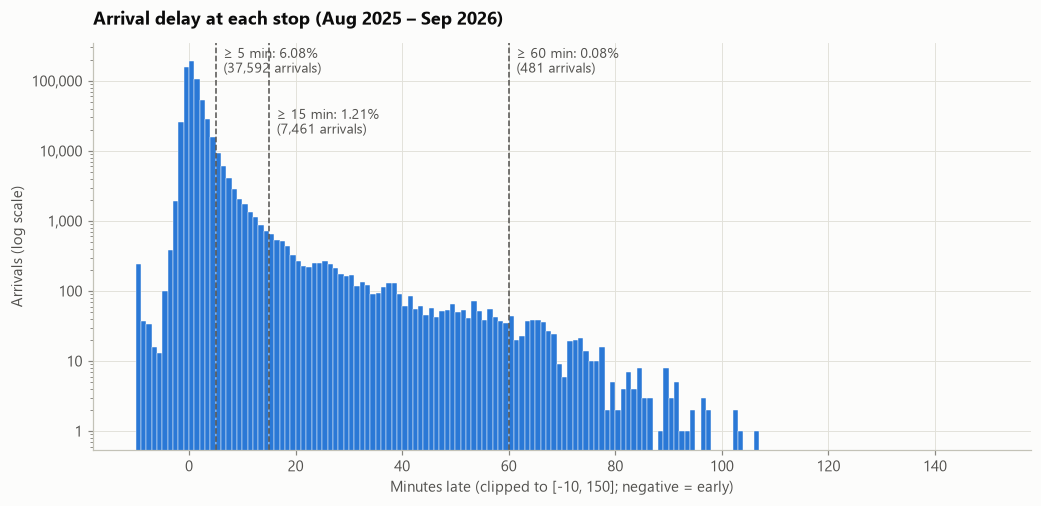

count    618522.00
mean          1.74
std           4.16
min         -10.06
50%           0.90
75%           1.93
90%           3.90
95%           5.92
99%          17.78
99.9%        56.91
max         106.95


In [10]:
d = stop_level["delay_min"]
lo, hi = -10, 150
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.hist(d.clip(lo, hi), bins=np.arange(lo, hi + 1, 1), color=BLUE, edgecolor=SURFACE, linewidth=0.3)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(thousands)
for x, y in [(ON_TIME_MIN, 0.99), (15, 0.84), (SEVERE_MIN, 0.99)]:
    ax.axvline(x, color=INK2, linewidth=1, linestyle="--")
    ax.annotate(f"≥ {x} min: {(d >= x).mean():.2%}\n({(d >= x).sum():,} arrivals)", (x, y), xycoords=("data", "axes fraction"),
                xytext=(5, 0), textcoords="offset points", va="top", fontsize=9, color=INK2)
ax.set_title(f"Arrival delay at each stop ({stop_level.service_date.min():%b %Y} – {stop_level.service_date.max():%b %Y})")
ax.set_xlabel(f"Minutes late (clipped to [{lo}, {hi}]; negative = early)"); ax.set_ylabel("Arrivals (log scale)")
plt.show()
print(d.describe(percentiles=[.5, .75, .9, .95, .99, .999]).round(2).to_string())

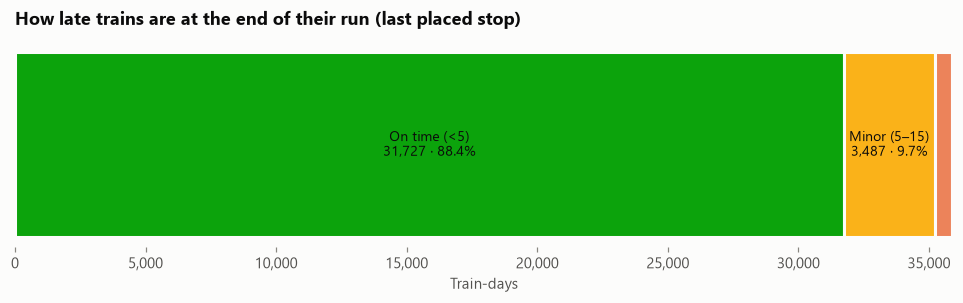

,train_days,share
severity,,
On time (<5),31727,88.36%
Minor (5–15),3487,9.71%
Major (15–60),683,1.90%
Severe (60+),11,0.03%


In [11]:
counts = trip_end["severity"].value_counts().reindex(list(SEVERITY))
fig, ax = plt.subplots(figsize=(11, 2.4))
left = 0
for label, n in counts.items():
    ax.barh(0, n, left=left, color=SEVERITY[label], edgecolor=SURFACE, linewidth=2)
    if n / counts.sum() > 0.04:
        ax.annotate(f"{label}\n{n:,} · {n / counts.sum():.1%}", (left + n / 2, 0), ha="center", va="center", fontsize=9, color=INK)
    left += n
ax.set_xlim(0, counts.sum()); ax.set_yticks([]); ax.grid(False); ax.spines[["left", "bottom"]].set_visible(False)
ax.xaxis.set_major_formatter(thousands)
ax.set_title("How late trains are at the end of their run (last placed stop)")
ax.set_xlabel("Train-days")
plt.show()
counts.to_frame("train_days").assign(share=lambda t: (t.train_days / t.train_days.sum()).map("{:.2%}".format))

### Corrected vs. production: where did the >1 hour delays go?

An exceedance curve (the share of arrivals *at least* this late) puts both pipelines on one axis.
The tail is much easier to read this way than in two overlaid histograms.

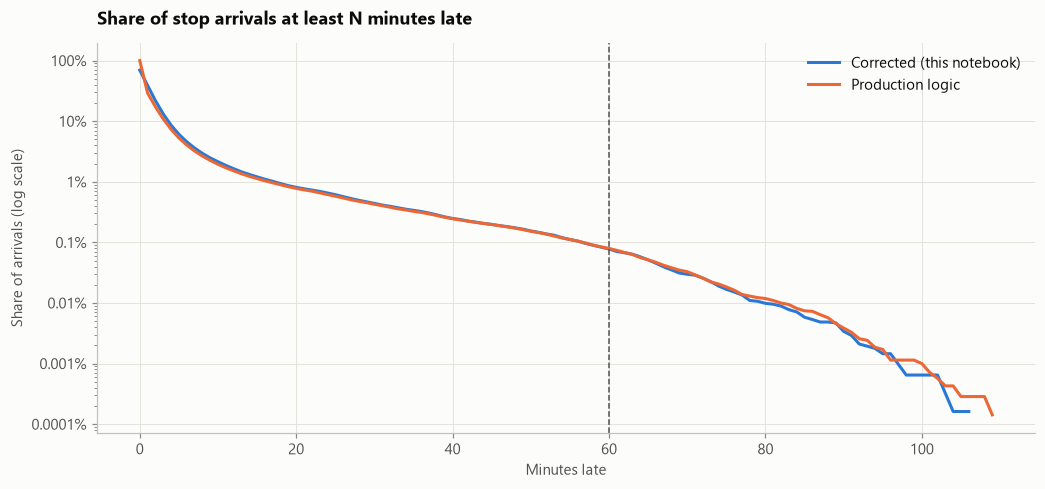

arrivals ≥ 60 min late: corrected 481, production 557


In [12]:
x = np.arange(0, 181)
exceed = lambda s: (s.to_numpy()[:, None] >= x[None, :]).mean(axis=0)
curves = {"Corrected (this notebook)": (exceed(stop_level["delay_min"]), BLUE),
          "Production logic": (exceed(prod["delay_min"]), ORANGE)}

fig, ax = plt.subplots(figsize=(11, 4.6))
for label, (curve, color) in curves.items():
    ax.plot(x[curve > 0], curve[curve > 0], color=color, label=label)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v * 100:g}%"))
ax.axvline(SEVERE_MIN, color=INK2, linewidth=1, linestyle="--")
ax.set_title("Share of stop arrivals at least N minutes late")
ax.set_xlabel("Minutes late"); ax.set_ylabel("Share of arrivals (log scale)")
ax.legend(loc="upper right")
plt.show()
print(f"arrivals ≥ {SEVERE_MIN} min late: corrected {(stop_level.delay_min >= SEVERE_MIN).sum():,}, "
      f"production {(prod.delay_min >= SEVERE_MIN).sum():,}")

In [13]:
# Production's ≥60-min arrivals: what does the corrected method say about the same train/stop/day?
p60 = both[both.delay_min >= SEVERE_MIN]
why_prod = pd.Series(np.select(
    [p60.corr_delay >= SEVERE_MIN, p60.corr_delay.notna(), p60.method.notna(), p60.method.isna()],
    ["corrected also ≥ 60", "corrected < 60: closest ping or stale timetable", "corrected: no placed arrival (phantom)",
     "stop not in the timetable in effect"], "other")).value_counts()

# Corrected ≥60-min arrivals: what did production record?
c60 = (stop_level[stop_level.delay_min >= SEVERE_MIN]
       .merge(prod.rename(columns={"date": "service_date", "delay_min": "prod_delay"})[KEYS + ["prod_delay", "raw_delay_min"]], on=KEYS, how="left"))
why_corr = pd.Series(np.select(
    [c60.prod_delay >= SEVERE_MIN, c60.prod_delay.isna(), c60.raw_delay_min.lt(-100) | c60.raw_delay_min.gt(500), c60.prod_delay < SEVERE_MIN],
    ["production also ≥ 60", "production has no arrival (train/stop not in 2024-25 timetable)", "production zeroed it (outside −100..500)",
     "production < 60 (earlier approach ping or stale timetable)"], "other")).value_counts()
display(why_prod.to_frame("production ≥ 60 min"), why_corr.to_frame("corrected ≥ 60 min"))

,production ≥ 60 min
corrected also ≥ 60,427
corrected: no placed arrival (phantom),111
corrected < 60: closest ping or stale timetable,19


,corrected ≥ 60 min
production also ≥ 60,426
production < 60 (earlier approach ping or stale timetable),30
production has no arrival (train/stop not in 2024-25 timetable),25


### Do badly delayed trains fall out of the data?

One way long delays could go missing: the worst-disrupted trains stop being tracked (terminated
short, passengers bused, GPS unit off). If so, runs with big delays early on should lose tracking
well before their final stop more often than on-time runs.

In [14]:
runs = (placed.groupby(["service_date", "train"])
        .agg(worst=("delay_min", "max"), last_stops_to_end=("stops_to_end", "min")))
runs["band"] = pd.cut(runs.worst, [-np.inf, 5, 15, 30, 60, np.inf], right=False,
                      labels=["< 5", "5–15", "15–30", "30–60", "60+"])
(runs.groupby("band", observed=True)
     .agg(train_days=("worst", "size"), tracking_lost_3plus_stops_early=("last_stops_to_end", lambda s: (s > 3).mean()))
     .style.format({"train_days": "{:,}", "tracking_lost_3plus_stops_early": "{:.1%}"}))

,train_days,tracking_lost_3plus_stops_early
band,,
< 5,"32,222",5.8%
5–15,"5,051",5.2%
15–30,560,6.6%
30–60,273,14.7%
60+,84,85.7%


## 6. Delays over time

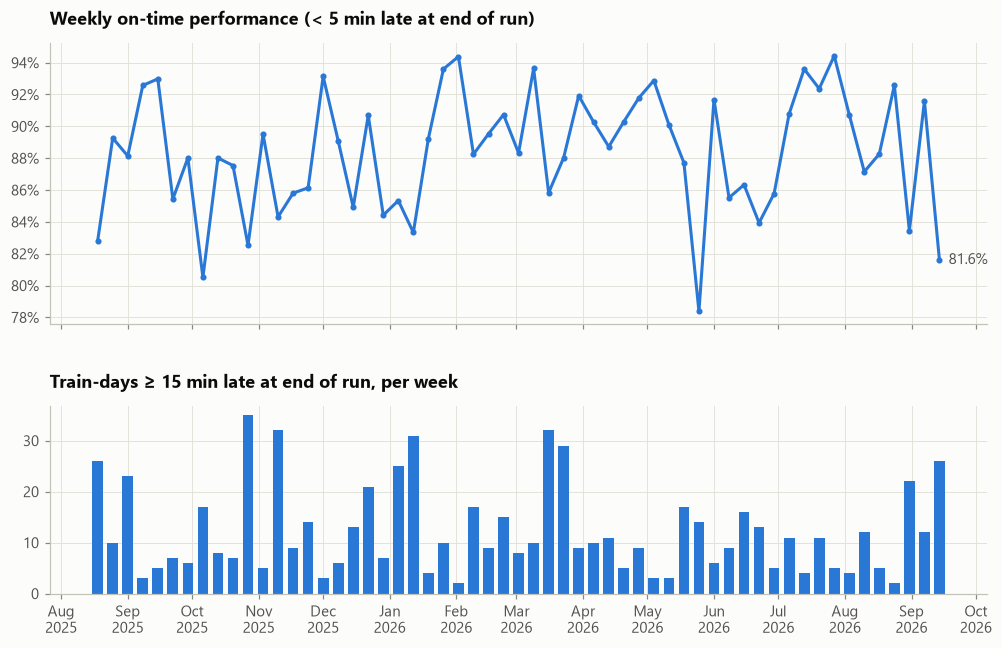

service_date,train,direction,station,scheduled,actual,delay_min,method
Fri 2025-12-19,527,Northbound,South San Francisco Caltrain Station,19:09,20:22,73,confirmed (ping ≤ radius)
Tue 2026-02-10,527,Northbound,South San Francisco Caltrain Station,19:09,20:21,73,confirmed (ping ≤ radius)
Wed 2026-09-02,523,Northbound,Millbrae,18:04,19:16,73,confirmed (ping ≤ radius)
Mon 2025-08-18,503,Northbound,South San Francisco Caltrain Station,07:09,08:20,72,confirmed (ping ≤ radius)
Mon 2025-08-18,401,Northbound,Millbrae,06:33,07:40,68,confirmed (ping ≤ radius)
Thu 2025-11-06,518,Southbound,Sunnyvale,17:09,18:15,67,confirmed (ping ≤ radius)
Thu 2025-11-06,527,Northbound,South San Francisco Caltrain Station,19:09,20:14,66,confirmed (ping ≤ radius)
Tue 2026-02-10,526,Southbound,Sunnyvale,19:09,20:13,65,confirmed (ping ≤ radius)
Mon 2026-06-22,510,Southbound,Sunnyvale,09:09,10:13,65,confirmed (ping ≤ radius)
Thu 2025-11-06,515,Northbound,22nd Street,16:16,17:18,63,confirmed (ping ≤ radius)


In [15]:
tv = trip_end.set_index("service_date")["delay_min"]
weekly = pd.DataFrame({"otp": (tv < ON_TIME_MIN).resample("W-MON").mean(),
                       "severe": (tv >= 15).resample("W-MON").sum(),
                       "n": tv.resample("W-MON").size()})
weekly = weekly[weekly.n >= 200]  # skip partial / outage weeks

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 2], "hspace": 0.35})
a1.plot(weekly.index, weekly.otp, color=BLUE, marker="o", markersize=3)
a1.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
a1.set_title(f"Weekly on-time performance (< {ON_TIME_MIN} min late at end of run)")
a1.annotate(f"{weekly.otp.iloc[-1]:.1%}", (weekly.index[-1], weekly.otp.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=INK2)
a2.bar(weekly.index, weekly.severe, width=5, color=BLUE)
a2.set_title("Train-days ≥ 15 min late at end of run, per week")
month_axis(a2)
plt.show()

worst = trip_end.sort_values("delay_min", ascending=False).head(15)
(worst[["service_date", "train", "direction", "station", "scheduled", "actual", "delay_min", "method"]]
 .style.format({"delay_min": "{:.0f}", "service_date": "{:%a %Y-%m-%d}", "scheduled": "{:%H:%M}", "actual": "{:%H:%M}"})
 .hide(axis="index"))

## 7. When are trains late? Day of week × scheduled hour

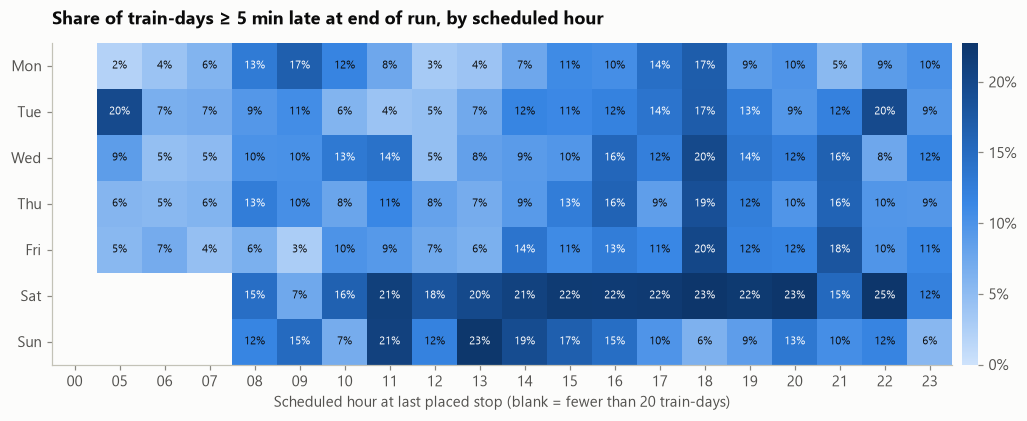

In [16]:
t = trip_end.assign(hour=trip_end.scheduled.dt.hour.clip(upper=23))
share = t.pivot_table(index="weekday", columns="hour", values="delay_min", aggfunc=lambda s: (s >= ON_TIME_MIN).mean())
n = t.pivot_table(index="weekday", columns="hour", values="delay_min", aggfunc="size")
order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
share = share.reindex(order).where(n.reindex(order) >= 20)
vmax = np.nanpercentile(share.values, 98)

fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(share.values, cmap=SEQ, aspect="auto", vmin=0, vmax=vmax)
ax.set_xticks(range(len(share.columns))); ax.set_xticklabels([f"{h:02d}" for h in share.columns])
ax.set_yticks(range(7)); ax.set_yticklabels(order); ax.grid(False)
for (i, j), v in np.ndenumerate(share.values):
    if not np.isnan(v):
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7, color="white" if v > 0.55 * vmax else INK)
ax.set_title(f"Share of train-days ≥ {ON_TIME_MIN} min late at end of run, by scheduled hour")
ax.set_xlabel("Scheduled hour at last placed stop (blank = fewer than 20 train-days)")
cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.03, format=PercentFormatter(1, decimals=0)); cb.outline.set_visible(False)
plt.show()

## 8. Where does delay build up along the line?

Stations are ordered south → north. A train that leaves on time but runs late by the end shows up
as a line that climbs in its direction of travel. Weekdays only, so the weekend timetable
doesn't blur the picture.

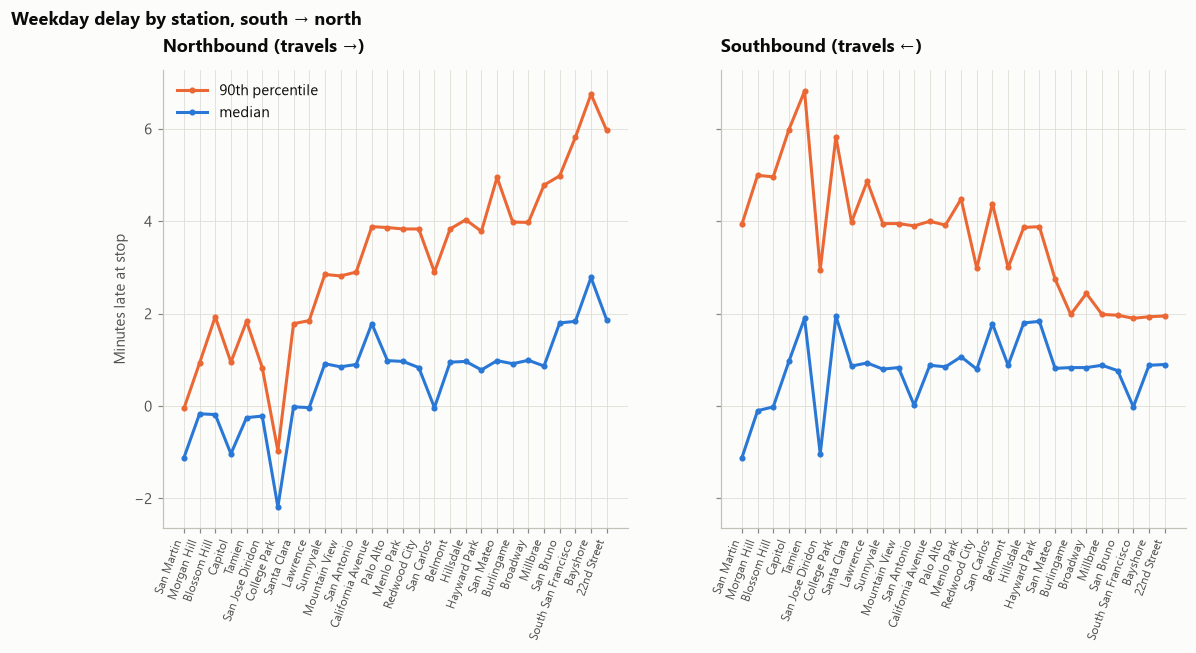

In [17]:
wk = stop_level[~stop_level.weekday.isin(["Sat", "Sun"]) & ~stop_level.is_terminal]  # terminals are almost never observed
station_order = sched.groupby("station")["stop_lat"].mean().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharey=True)
for ax, direction in zip(axes, ["Northbound", "Southbound"]):
    g = wk[wk.direction == direction].groupby("station")["delay_min"]
    prof = (g.quantile([.5, .9]).unstack().where(g.size() >= 50)
            .reindex(station_order).dropna())
    prof.index = prof.index.str.replace(" Caltrain Station", "").str.replace(" Station", "")
    xs = np.arange(len(prof))
    ax.plot(xs, prof[0.9], color=ORANGE, marker="o", markersize=3, label="90th percentile")
    ax.plot(xs, prof[0.5], color=BLUE, marker="o", markersize=3, label="median")
    ax.set_xticks(xs); ax.set_xticklabels(prof.index, rotation=70, ha="right", fontsize=8)
    ax.set_title(f"{direction} (travels {'→' if direction == 'Northbound' else '←'})")
axes[0].set_ylabel("Minutes late at stop"); axes[0].legend(loc="upper left")
fig.suptitle("Weekday delay by station, south → north", x=0.01, ha="left", fontweight="bold")
plt.show()

## 9. Which trains are chronically late?

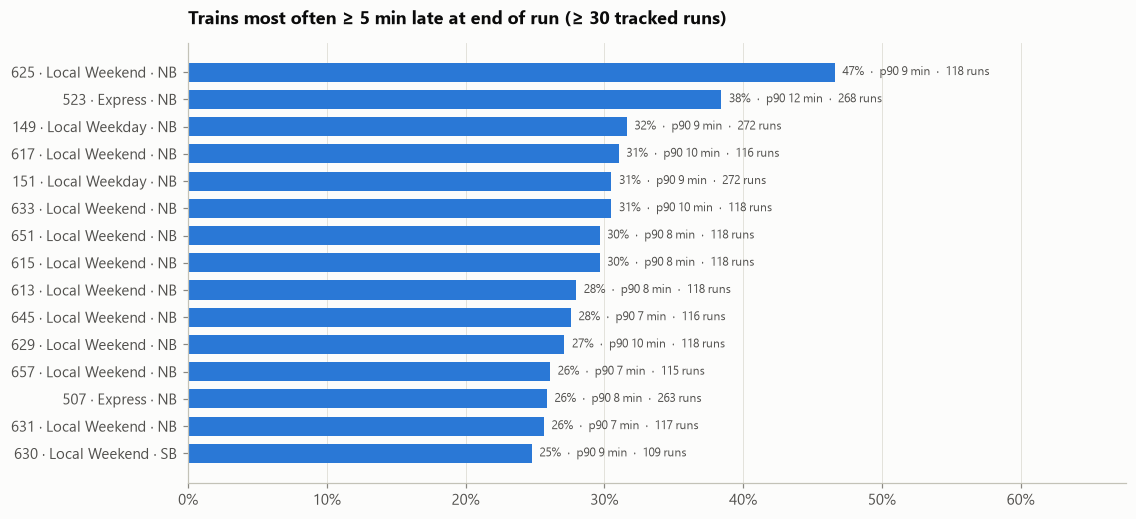

In [18]:
by_train = (trip_end.groupby(["train", "direction", "route_id"])
            .agg(runs=("delay_min", "size"), late_share=("delay_min", lambda s: (s >= ON_TIME_MIN).mean()),
                 p90=("delay_min", lambda s: s.quantile(.9)))
            .query("runs >= 30").sort_values("late_share", ascending=False).reset_index())
top = by_train.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.barh(top.train + " · " + top.route_id + " · " + top.direction.str[0] + "B", top.late_share, color=BLUE, height=0.7)
for y, r in enumerate(top.itertuples()):
    ax.annotate(f"{r.late_share:.0%}  ·  p90 {r.p90:.0f} min  ·  {r.runs} runs", (r.late_share, y), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK2)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.grid(axis="y", visible=False)
ax.set_xlim(0, top.late_share.max() * 1.45)
ax.set_title(f"Trains most often ≥ {ON_TIME_MIN} min late at end of run (≥ 30 tracked runs)")
plt.show()

## 10. Trains that never showed up (a cancellation proxy)

`VehicleMonitoring` only lists trains that are running, so a cancelled train is simply absent.
Counted here: scheduled train-days with **zero pings**. Collector blind spots are excluded, meaning
trains scheduled inside the 00:00–03:00 gap and days when the collector itself was mostly
down. Treat this as an upper bound on cancellations: a train whose GPS unit was off counts too.

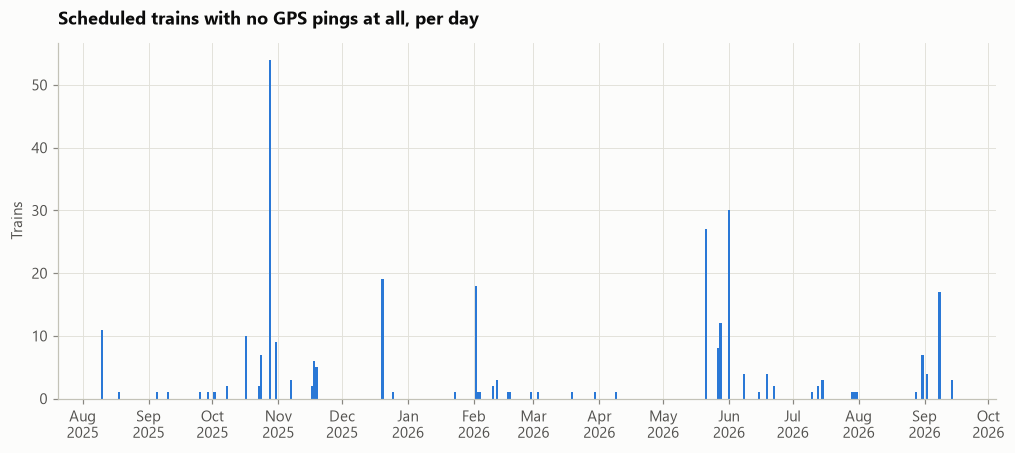

299 of 37,486 eligible scheduled train-days never appeared (0.80%); 2 low-coverage days excluded


,scheduled,never_seen
service_date,,
2025-10-28,108,54
2026-06-01,108,30
2026-05-21,108,27
2025-12-20,62,19
2026-02-02,108,18
2026-09-08,108,17
2026-05-28,108,12
2025-08-10,62,11
2025-10-17,108,10


In [19]:
run_days = (sched.groupby(["service_date", "train"]).agg(first=("scheduled", "min"), last=("scheduled", "max"))
            .join(runs_seen.set_index(["service_date", "train"])).fillna({"train_seen": False}).reset_index())
day_start = run_days.service_date + pd.Timedelta(hours=SERVICE_DAY_START_HOUR)
in_window = (run_days["first"] >= day_start) & (run_days["last"] < run_days.service_date + pd.Timedelta(days=1))
healthy = daily_minutes[daily_minutes >= 0.6 * daily_minutes.rolling(15, center=True, min_periods=1).median()].index
eligible = run_days[in_window & run_days.service_date.isin(healthy)]
missing = eligible.groupby("service_date").agg(scheduled=("train_seen", "size"), never_seen=("train_seen", lambda s: int((~s.astype(bool)).sum())))

fig, ax = plt.subplots()
ax.bar(missing.index, missing.never_seen, width=1, color=BLUE)
ax.set_title("Scheduled trains with no GPS pings at all, per day"); ax.set_ylabel("Trains")
month_axis(ax)
plt.show()
never = ~eligible.train_seen.astype(bool)
print(f"{never.sum():,} of {len(eligible):,} eligible scheduled train-days never appeared ({never.mean():.2%}); "
      f"{len(daily_minutes) - len(healthy)} low-coverage days excluded")
missing.sort_values("never_seen", ascending=False).head(10)

## 11. Live cancellations from the `TripUpdates` feed (optional)

511.org publishes GTFS-RT `TripUpdates` for Caltrain as protobuf at
`https://api.511.org/transit/tripupdates?agency=CT`. Cancelled trips carry
`schedule_relationship = CANCELED`, and skipped stops appear as `SKIPPED` stop-time updates. The
feed only describes *right now*, so building a cancellation history means logging it going
forward: for example, storing each poll's cancelled/skipped trip IDs next to the existing
`VehicleMonitoring` collection.

This cell runs only if `API_KEY` is set and `gtfs-realtime-bindings` is installed
(`uv pip install gtfs-realtime-bindings`).

In [20]:
api_key = os.environ.get("API_KEY")
try:
    import requests
    from google.transit import gtfs_realtime_pb2
except ImportError:
    gtfs_realtime_pb2 = None

if not api_key or gtfs_realtime_pb2 is None:
    print("Skipped: set API_KEY and install gtfs-realtime-bindings to query TripUpdates.")
else:
    resp = requests.get("https://api.511.org/transit/tripupdates", params={"api_key": api_key, "agency": "CT"}, timeout=30)
    resp.raise_for_status()
    feed_msg = gtfs_realtime_pb2.FeedMessage()
    feed_msg.ParseFromString(resp.content)
    TD, STU = gtfs_realtime_pb2.TripDescriptor, gtfs_realtime_pb2.TripUpdate.StopTimeUpdate
    live = pd.DataFrame([{
        "trip_id": e.trip_update.trip.trip_id,
        "trip_status": TD.ScheduleRelationship.Name(e.trip_update.trip.schedule_relationship),
        "skipped_stops": sum(s.schedule_relationship == STU.SKIPPED for s in e.trip_update.stop_time_update),
    } for e in feed_msg.entity if e.HasField("trip_update")])
    print(f"feed time {pd.Timestamp(feed_msg.header.timestamp, unit='s', tz='UTC').tz_convert('America/Los_Angeles'):%Y-%m-%d %H:%M %Z}, {len(live)} trips")
    display(live["trip_status"].value_counts().to_frame() if len(live) else live)

Skipped: set API_KEY and install gtfs-realtime-bindings to query TripUpdates.


## Findings (snapshot of 2026-09-14)

**On the review's three points**

- **Calendar-day anchoring is real, and the bigger problem is upstream of it.** Production zeroes
  ~1,500 raw delays outside −100..500 min (mostly late-evening trains scored against a wrapped
  `00:xx` time) and ~340k small negatives. About half of all production arrivals end up as
  exactly 0. But the collector records essentially **nothing between 00:00 and 03:00**. The
  midnight processing flow appears to block it, so post-midnight arrivals are missing rather than
  mis-scored. Fixing the anchoring alone won't bring them back; fixing the scheduling will.
- **Phantom arrivals: yes, and an unused threshold isn't the only cause.** The realtime `stop_id`
  moves on to the next station while the train is still at the platform. Matching only against the
  reported stop means production usually never sees the at-platform ping and falls back to an
  approach ping about a minute earlier. Matching all pings with a 400 m radius plus bracketing
  places ~85% of stop-calls. The ~110 hour-plus production arrivals with no placed arrival here
  are the phantoms the reviewer described.
- **Cancellations** can't be seen in `VehicleMonitoring`. About 0.8% of scheduled train-days never
  show up at all, clustered on a handful of disruption days. `TripUpdates` exposes `CANCELED`
  and `SKIPPED` live, but has no history, so it needs to be logged going forward.

**On the "missing" hour-plus delays**

- Production's `processed_arrivals.csv` *does* contain them: 557 unique ≥ 60-min stop arrivals,
  max ~110 min, which matches this reproduction exactly. Nothing in the export caps them.
- They're hard to see because (a) every chart aggregates arrivals, and the CSV repeats each
  arrival ~6× (once per ping), (b) no histogram existed (added above, log scale), and
  (c) the worst disruptions tend to land exactly where the data is blind: after midnight, at
  terminals the feed never reaches, and trains that never ran. Badly delayed trains don't drop
  out of the feed more often than on-time ones.

**Other things worth fixing in the pipeline**

1. Timetable: production still uses the Sep 2024 – May 2025 GTFS, and ~40% of its arrivals are
   scored against a scheduled time that has since changed (usually by ~1 min).
2. One row per ping in `processed_arrivals.csv`: dedupe to one row per (service date, train, stop).
3. Trains vanish ~2–3 km before their terminal, so "on time at final stop" can't come from this
   feed. Use the last observed stop, or interpolate using `TripUpdates` predictions.
4. Holiday calendars: feeds omit holidays that predate publication (Labor Day 2025 ran the Sunday
   timetable). Infer the day type from the trains actually observed.

## Summary

In [21]:
pd.Series({
    "pings analysed": f"{len(pings):,}",
    "placed stop arrivals (non-origin)": f"{len(stop_level):,}",
    "  of which interpolated": f"{stop_level.method.str.startswith('interpolated').mean():.1%}",
    f"on time at end of run (< {ON_TIME_MIN} min)": f"{(trip_end.delay_min < ON_TIME_MIN).mean():.1%}",
    "median / p90 / p99 stop delay (min)": " / ".join(f"{stop_level.delay_min.quantile(q):.1f}" for q in (.5, .9, .99)),
    f"stop arrivals ≥ {SEVERE_MIN} min late: corrected": f"{(stop_level.delay_min >= SEVERE_MIN).sum():,}",
    f"stop arrivals ≥ {SEVERE_MIN} min late: production logic": f"{(prod.delay_min >= SEVERE_MIN).sum():,}",
    "production rows per real arrival": f"{rows_per_arrival.mean():.1f}",
    "eligible scheduled train-days never seen": f"{never.sum():,} ({never.mean():.2%})",
}).to_frame("value")

,value
pings analysed,"4,331,714"
placed stop arrivals (non-origin),"618,522"
of which interpolated,1.8%
on time at end of run (< 5 min),88.4%
median / p90 / p99 stop delay (min),0.9 / 3.9 / 17.8
stop arrivals ≥ 60 min late: corrected,481
stop arrivals ≥ 60 min late: production logic,557
production rows per real arrival,6.2
eligible scheduled train-days never seen,299 (0.80%)
